# Data Cleaning, Exploration, Translation, and Corpus Preparation

This notebook documents the full preprocessing workflow used to transform raw insurance reviews into a cleaned corpus that can support the downstream modelling notebooks. The objective is not only to clean the data, but also to justify each design choice, validate that each transformation behaves as expected, and preserve intermediate evidence suitable for an academic submission.

## Learning Objectives
- Understand the structure, limitations, and imbalance patterns of the raw review dataset.
- Apply defensible cleaning steps to French customer reviews before translation.
- Build two English text variants tailored to different NLP methods: stronger cleaning for TF-IDF and topic models, lighter cleaning for embedding-based models.
- Validate each transformation with sanity checks, intermediate outputs, and concrete examples of problematic cases.
- Produce a final cleaned dataset that can be reused consistently by the modelling notebooks.


## Academic Roadmap
Each section follows the same pattern: explain the purpose of the step, run the code, inspect intermediate outputs, and check whether the result is plausible. That structure makes the notebook easier to grade and also reduces the risk of silent preprocessing errors.


### Import 

In [ ]:
# Purpose: Import.
# The intermediate output from this cell is kept intentionally for transparency and validation.
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
#from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from tqdm import tqdm   
tqdm.pandas()
import re
from spellchecker import SpellChecker
pd.set_option("display.max_colwidth", None)


ModuleNotFoundError: No module named 'spellchecker'

### Import of the full data for the final test

In [5]:
# Purpose: Import of the full data for the final test.
# The intermediate output from this cell is kept intentionally for transparency and validation.
folder = Path("Fichiers")
files = sorted(folder.glob("*.xlsx"))
dfs = [pd.read_excel(file) for file in files]
df_final = pd.concat(dfs, ignore_index=True)
df_final.to_excel(folder / "avis_concatenes.xlsx", index=False)

print(df_final.shape)
print(df_final.head())


(149740, 11)
   note              auteur  \
0   4.0   audurier-c-136272   
1   4.0       paul-a-122970   
2   1.0         kitty-38517   
3   1.0    laure97134-87907   
4   3.0  bourouane-l-129916   

                                                avis             assureur  \
0  La personne au téléphone était Clair et sympat...  L'olivier Assurance   
1  Satisfait.\n\nRéactivité, simplicité. Prix att...           APRIL Moto   
2  Assureur à fuir, n assure pas ses responsabili...            SwissLife   
3  Voilà 3 mois que la GMF me fait attendre pour ...                  GMF   
4  Je suis bien avec cet assurance.elle est prati...  L'olivier Assurance   

      produit   type date_publication    date_exp  \
0        auto  train       06/10/2021  01/10/2021   
1        moto  train       09/07/2021  01/07/2021   
2         vie  train       15/10/2020  01/10/2020   
3  habitation  train       03/03/2020  01/03/2020   
4        auto  train       28/08/2021  01/08/2021   

                  

### For the rest we are going to work on a smaller dataset in order to test and make it faster

In [7]:
# Purpose: For the rest we are going to work on a smaller dataset in order to test and make it faster.
# The intermediate output from this cell is kept intentionally for transparency and validation.
folder = Path("Fichiers")

wanted = {"avis_1_traduit.xlsx", "avis_2_traduit.xlsx", "avis_34_traduit.xlsx"}

files = sorted([
    f for f in folder.glob("*.xlsx")
    if not f.name.startswith("~$") and f.name in wanted
])

dfs = [pd.read_excel(file) for file in files]


df_final = pd.concat(dfs, ignore_index=True)
df_final.to_excel(folder / "avis_concatenes_short.xlsx", index=False)
print(df_final.shape)


(3000, 11)


## Early Sanity Checks
Before exploring the corpus in depth, we confirm that the merged table has the expected size, the expected split between labelled and unlabelled reviews, and no obviously broken columns. These checks are intentionally simple because they are meant to catch data-loading issues immediately.


## Simple exploration

In [8]:
# Sanity check the merged dataset before deeper exploration.
print('Merged dataset shape:', df_final.shape)
print('Columns available:', list(df_final.columns))
print('Split between train and test rows:')
print(df_final['type'].value_counts(dropna=False))
print('Missing values per column:')
print(df_final.isna().sum())


Merged dataset shape: (3000, 11)
Columns available: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']
Split between train and test rows:
type
train    2000
test     1000
Name: count, dtype: int64
Missing values per column:
note                1000
auteur                 0
avis                   0
assureur               0
produit                0
type                   0
date_publication       0
date_exp               0
avis_en                0
avis_cor            3000
avis_cor_en         3000
dtype: int64


In [ ]:
df_final.head()


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous \nDes prix attractif et services de qualité et rapidité",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, speed, and I recommend this company for you\nAttractive prices and quality services and speed",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous avez un problème avec votre site internet ,impossible de déclarer un sinistre en ligne après plusieurs tentatives déclaration faite par téléphone ou tout c'est très bien passé , interlocutrice compétente et très agréable",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have a problem with your website, impossible to declare an online disaster after several attempts declared by phone or everything went very well, competent and very pleasant interlocutor",NaN,NaN
2,5.0,virginie-t-107352,"Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter à la voiture, l'option tranquiliter et zero franchise ce qui est tout a fait plaisant",Direct Assurance,auto,train,21/03/2021,01/03/2021,"Very affordable price Several options are available to us such as the connecting box to the car, the quiet and zero franchise option which is quite pleasant",NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapide de votre service .je vous en remercie, vous êtes une assurance la moins cher sur le marche, Cordialement.",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response from your service. I thank you, you are a cheapest insurance on the walk, cordially.",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cette ""mutuelle"" qui n'a plus rien d'une Mutuelle, la recherche du profit immédiat est devenu leur priorité. à l'agence on ne sait que essayer de vous fourguer des contrats inutiles, on vous fait payer une protection juridique sur chaque contrat mais vous ne serez défendu qu'une fois! dès qu'il y a le moindre sinistre il ne sont pas là pour vous défendre mais au contraire pour vous mettre d'office tous les tords pour faire descendre votre bonus qui est trop haut ! Bref ils n'ont plus qu'un seul but vous faire payer le plus possible. Hélas c'est maintenant le lot de tous les assureurs. Donc cherchez à payer le moins possible et surtout de ne pas avoir besoin d'eux !!!",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappointed with this ""mutual"" which is no longer a mutual, the search for immediate profit has become their priority. At the agency we do not know that trying to run unnecessary contracts, we make you pay legal protection on each contract but you will only be defended once! As soon as there is the slightest claim there are not there to defend you but on the contrary to automatically put you all the twists to bring down your bonus which is too high! In short, they have only one goal to make you pay as much as possible. Alas it is now the lot of all insurers. So find out to pay as little as possible and especially not to need them !!!",NaN,NaN


In [ ]:
df_final.shape


(3000, 11)

I am deleting some columns because accidently in previous work I added some columns to all the excel.

In [ ]:
df_final.drop(columns=["avis_cor", "avis_cor_en"], inplace=True)

In [ ]:
df_final.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous \nDes prix attractif et services de qualité et rapidité",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, speed, and I recommend this company for you\nAttractive prices and quality services and speed"
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous avez un problème avec votre site internet ,impossible de déclarer un sinistre en ligne après plusieurs tentatives déclaration faite par téléphone ou tout c'est très bien passé , interlocutrice compétente et très agréable",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have a problem with your website, impossible to declare an online disaster after several attempts declared by phone or everything went very well, competent and very pleasant interlocutor"
2,5.0,virginie-t-107352,"Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter à la voiture, l'option tranquiliter et zero franchise ce qui est tout a fait plaisant",Direct Assurance,auto,train,21/03/2021,01/03/2021,"Very affordable price Several options are available to us such as the connecting box to the car, the quiet and zero franchise option which is quite pleasant"
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapide de votre service .je vous en remercie, vous êtes une assurance la moins cher sur le marche, Cordialement.",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response from your service. I thank you, you are a cheapest insurance on the walk, cordially."
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cette ""mutuelle"" qui n'a plus rien d'une Mutuelle, la recherche du profit immédiat est devenu leur priorité. à l'agence on ne sait que essayer de vous fourguer des contrats inutiles, on vous fait payer une protection juridique sur chaque contrat mais vous ne serez défendu qu'une fois! dès qu'il y a le moindre sinistre il ne sont pas là pour vous défendre mais au contraire pour vous mettre d'office tous les tords pour faire descendre votre bonus qui est trop haut ! Bref ils n'ont plus qu'un seul but vous faire payer le plus possible. Hélas c'est maintenant le lot de tous les assureurs. Donc cherchez à payer le moins possible et surtout de ne pas avoir besoin d'eux !!!",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappointed with this ""mutual"" which is no longer a mutual, the search for immediate profit has become their priority. At the agency we do not know that trying to run unnecessary contracts, we make you pay legal protection on each contract but you will only be defended once! As soon as there is the slightest claim there are not there to defend you but on the contrary to automatically put you all the twists to bring down your bonus which is too high! In short, they have only one goal to make you pay as much as possible. Alas it is now the lot of all insurers. So find out to pay as little as possible and especially not to need them !!!"


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              2000 non-null   float64
 1   auteur            3000 non-null   object 
 2   avis              3000 non-null   object 
 3   assureur          3000 non-null   object 
 4   produit           3000 non-null   object 
 5   type              3000 non-null   object 
 6   date_publication  3000 non-null   object 
 7   date_exp          3000 non-null   object 
 8   avis_en           3000 non-null   object 
dtypes: float64(1), object(8)
memory usage: 211.1+ KB


One interesting things is that there is no missing values except for note but it is normal because of the type = test

In [ ]:
df_final[df_final["type"]=="test"].head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en
2000,NaN,lt25-71932,Cliente de +25 ans avec aucun sinistre sauf celui d un cambriolage en nov 2018. Cela fait +3 mois que mon dossier traîne encore..C est la 1ère fois je ne m attendais pas à ce genre de traitement,MACIF,habitation,test,06/03/2019,01/03/2019,Customer of +25 years with no claim except that of a burglary in Nov 2018. It has been +3 months that my file still hangs out ... it is the first time I did not expect this kind of treatment
2001,NaN,kolbu-71178,A assuré puis supprimé mon assurance pour des raisons informatiques. La maison est soudainement devenue trop grande pour être assurée alors que la surface (les plans avaient été communiqués) n'avait pas varié. Je n'ai eu affaire qu'à des passe plats... c'est la faute à l'informatique...,MACIF,habitation,test,11/02/2019,01/02/2019,Assured and then deleted my insurance for computer reasons. The house suddenly became too large to be assured while the surface (the plans had been communicated) had not varied. I was only dealing with dishes ... It's the fault of computer science ...
2002,NaN,syl-vie66-71161,"je suis assurée à la Macif depuis presque un an pour mon assurance habitation et suis bien décidée à partir très vite \nsuite à un sinistre arrivé hier, j'essaie de les contacté depuis ce matin et j'en suis à exactement 89 minutes d'attente hormis un répondeur qui me dit que mon appel est bien pris en compte, personne au bout du fils. J'ose même pas imaginer si j'étais en détresse",MACIF,habitation,test,11/02/2019,01/02/2019,"I have been assured at the Macif for almost a year for my home insurance and am determined to leave very quickly\nFollowing a sinister arrived yesterday, I try to contacted them since this morning and I am exactly 89 minutes of waiting except an answering machine who tells me that my call is taken into account, no one at the end of the son. I dare not even imagine if I was in distress"
2003,NaN,jct-69324,"Assuré à la Macif depuis 19 ans, mon assurance a été résilié pour cause de sinistralité trop forte (quelques dégats des eaux ces trois dernières années -du fait d'un voisin- et dont le remboursement par la macif est sans commune mesure avec les indemnités encaissées depuis 19 ans..). Je n'ai jamais reçu le recommandé (envoyé sans AR), je me suis donc retrouvé sans assurance moi et ma famille pendant 7 mois sans le savoir (c'est en passant un coup de fil sur un autre sujet que je l'ai appris...). J'ai posé réclamation et la réponse a été une fin de non recevoir sous forme administrative.",MACIF,habitation,test,11/12/2018,01/12/2018,"Insured at the Macif for 19 years, my insurance has been terminated due to too strong claims (some damage to water in the past three years - made from a neighbor - and whose reimbursement by the Macif is incommensurate with compensation collected for 19 years ..). I never received the recommended (sent without ar), so I found myself without insurance and my family for 7 months without knowing it (it is by making a phone call on another subject that I have it learned...). I made a complaint and the response was an end of not receiving in administrative form."
2004,NaN,fellabour-69016,Assureur vraiment a éviter Refuse de nous indemniser suite à un combriolage après une longue attente très déçue de votre part et de votre façon de traiter les dossiers,MACIF,habitation,test,30/11/2018,01/11/2018,Insurer really to avoid refuses to compensate us following a combriolating after a long wait very disappointed on your part and your way of processing the files


In [ ]:
(df_final["type"] == "test").sum()

np.int64(1000)

In [ ]:
df_final.describe()

,note
count,2000.000000
mean,2.790000
std,1.533974
min,1.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


The dataset contains 3000 observations and 9 relevant variables after removing accidental columns from previous work. The only missing values appear in the `note` column, with exactly 1000 missing entries. This is not a data quality issue: these missing ratings correspond to rows labeled as `type = test`, meaning that the target variable is intentionally unavailable for final evaluation.

This distinction is important because it confirms that the missingness is **structural rather than random**. In other words, we do not need to impute the missing ratings, since they are not unknown labels in the training data but simply the unlabeled portion of the dataset reserved for prediction.

From a modeling perspective, this means that all supervised experiments must be performed only on the training subset where `note` is available. The test subset must remain untouched and should only be used to generate final predictions. Treating these missing values incorrectly would create methodological errors and potentially leak information between training and evaluation stages.

## Exploration of the comments

We analyze the distribution of comment lengths using `str.len().describe()` to understand the variability in text size. This helps identify extremely short or unusually long reviews that may impact downstream NLP tasks.

In [ ]:
df_final["avis"].str.len().describe()

count    3000.000000
mean      392.815000
std       404.453563
min         3.000000
25%       167.000000
50%       237.000000
75%       462.000000
max      4245.000000
Name: avis, dtype: float64

The results show a high variability in comment lengths, with a standard deviation of 404. This indicates a strong dispersion in the size of the texts.

Some comments are very short (minimum length of 3), while others are extremely long (up to 4245 characters), highlighting the heterogeneity of the dataset.

In [ ]:
df_final[df_final["avis"]==" "].shape

(0, 9)

There are no empty comments

#### We will now focus on short comments to assess whether they contain enough information to be effectively used in our analysis.

In [ ]:
df_final[df_final["avis"].str.split().str.len() < 2]

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en
2531,NaN,fred-69689,Nul,Generali,credit,test,26/12/2018,01/12/2018,No
2649,NaN,abbealaoui-67975,.......,Cardif,credit,test,22/10/2018,01/10/2018,.......
2779,NaN,lounis-87207,Bof,Sogecap,vie,test,16/02/2020,01/02/2020,Bof


In [ ]:
df_final[df_final["avis"].str.split().str.len() < 3]

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en
1479,1.0,hiphop77-56472,à fuir,Cardif,credit,train,03/08/2017,01/08/2017,to flee
1513,3.0,kiki76-50866,la misere,L'olivier Assurance,auto,train,02/01/2017,01/01/2017,misery
2033,NaN,tontonbubu-54321,toujours present,MACIF,habitation,test,26/04/2017,01/04/2017,always present
2531,NaN,fred-69689,Nul,Generali,credit,test,26/12/2018,01/12/2018,No
2649,NaN,abbealaoui-67975,.......,Cardif,credit,test,22/10/2018,01/10/2018,.......
2779,NaN,lounis-87207,Bof,Sogecap,vie,test,16/02/2020,01/02/2020,Bof
2986,NaN,mary78-78290,Une CATASTROPHE,Carac,prevoyance,test,09/08/2019,01/08/2019,A disaster


The number of very short comments is extremely limited, with only a few entries containing fewer than 3 words. This suggests that most reviews are sufficiently detailed.

Even among these short comments, some still carry meaningful information (e.g., strong opinions), but their limited length may reduce their usefulness for certain NLP tasks.

## Duplicates

In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_final[df_final.duplicated()].head()

In [ ]:
df_final.drop_duplicates(inplace=True)

We identify duplicate entries in the dataset to avoid redundancy and potential bias in the analysis. Duplicate comments may appear multiple times and can distort the results if not handled properly.

## Visual exploration

#### Distribution of the notes

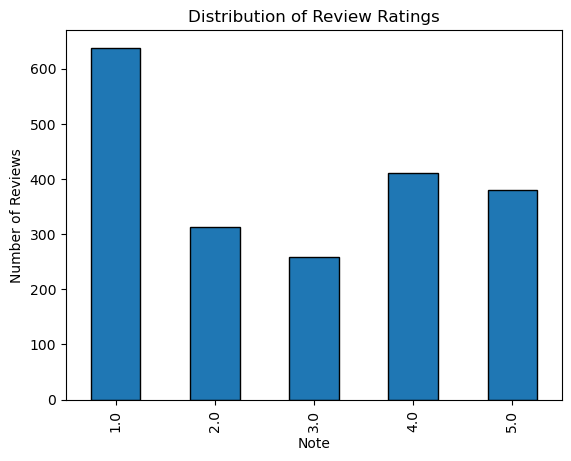

In [ ]:
counts = df_final["note"].value_counts().sort_index()

counts.plot(kind="bar", edgecolor="black")

plt.xlabel("Reviews")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Ratings")

plt.show()


In [ ]:
(df_final["note"].value_counts(normalize=True)*100).sort_index()

note
1.0    31.90
2.0    15.65
3.0    12.95
4.0    20.55
5.0    18.95
Name: proportion, dtype: float64

The rating distribution is clearly imbalanced. Among the labeled observations, 1-star reviews represent 31.9% of the data, whereas 3-star reviews account for only 12.95%. The other classes are more moderately represented: 2 stars correspond to 15.65%, 4 stars to 20.55%, and 5 stars to 18.95%.

This imbalance is not just a descriptive detail; it has direct methodological consequences. First, it indicates that the dataset contains proportionally more strongly negative feedback than neutral or mixed feedback. This is consistent with online review behavior in insurance services, where customers are often more motivated to write after a bad experience than after a routine positive one.

Second, this imbalance makes the prediction task more difficult than it may appear. A model can achieve a relatively acceptable overall accuracy simply by favoring the majority classes, especially 1-star reviews, while performing poorly on the less represented middle ratings. This is particularly problematic because intermediate ratings often correspond to more nuanced language that is harder to classify.

For this reason, model evaluation should not rely on accuracy alone. Metrics such as **macro-F1**, per-class precision/recall, and confusion matrices are more appropriate because they reflect performance across all rating levels rather than being dominated by the most frequent class.

#### Numbers of products

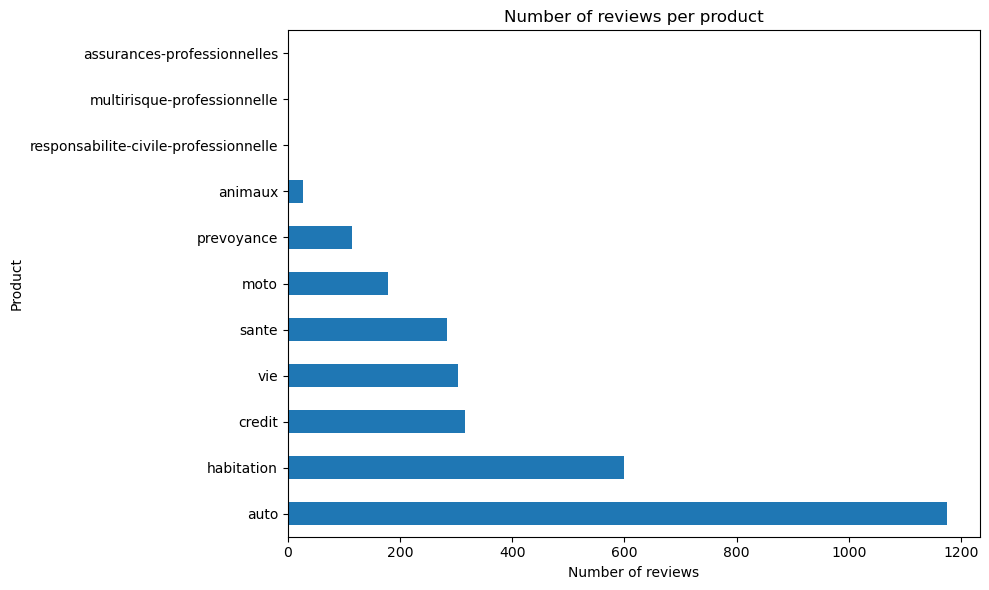

In [9]:
counts = df_final["produit"].value_counts()

plt.figure(figsize=(10,6))
counts.plot(kind="barh")

plt.title("Number of reviews per product")
plt.xlabel("Number of reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


The distribution of reviews across products is highly unbalanced. The auto category largely dominates with a significantly higher number of reviews compared to all other products.
Habitation also has a substantial number of reviews, followed by credit, vie, and santé, which form a middle group with moderate representation.
In contrast, categories such as animaux and professional insurance products have very few or almost no reviews.

#### Number of reviews per assurer

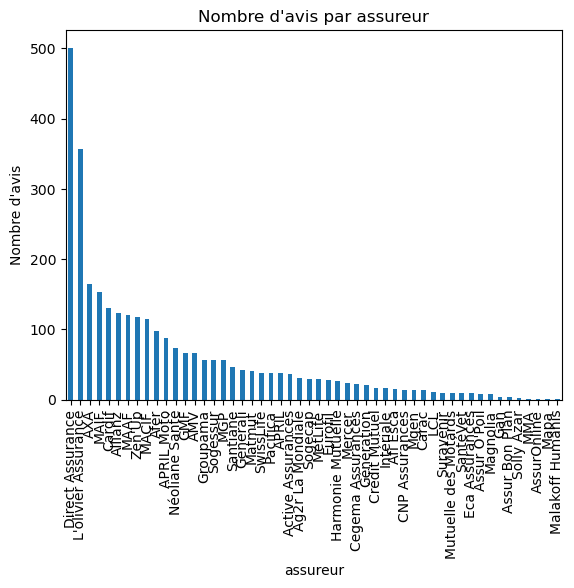

In [ ]:
df_final["assureur"].value_counts().plot(kind="bar")
plt.title("Number of reviews per insurer")
plt.ylabel("Number of reviews")
plt.show()

The number of reviews is not evenly distributed across products and insurers. Some categories appear much more frequently than others, which means the dataset is not only imbalanced in terms of ratings, but also in terms of business segments and companies.

This matters because linguistic patterns may depend on the product type. For example, vocabulary related to car insurance, health insurance, or credit insurance is not interchangeable. Similarly, users may mention specific administrative processes, claim situations, or customer service issues that are more common for some insurers than for others.

#### Average rating per insurer

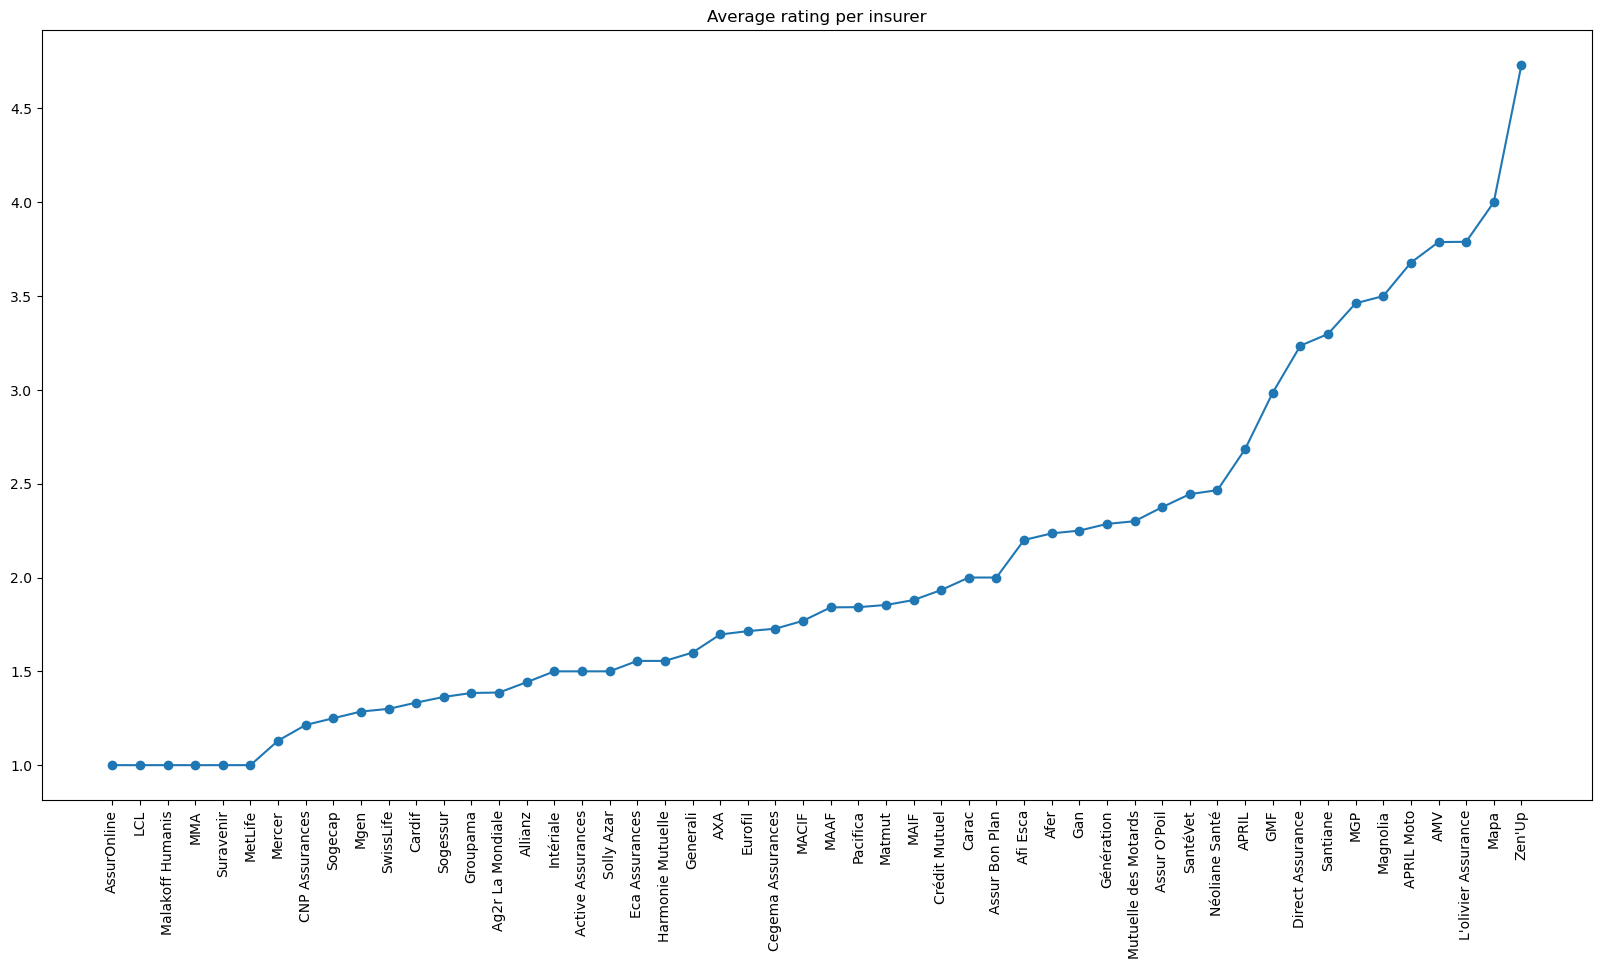

In [10]:
plt.figure(figsize=(20,10))

mean_notes = df_final.groupby("assureur")["note"].mean().sort_values()

plt.plot(mean_notes.index, mean_notes.values, marker="o")

plt.xticks(rotation=90)

plt.title("Average rating per insurer")

plt.show()


The average rating differs across insurers, which suggests that the customer experience described in the reviews is not homogeneous from one company to another. These differences may reflect actual variation in service quality, claims management, responsiveness, or customer expectations.

From a modeling perspective, insurer identity may correlate with rating, which can help prediction. But this also introduces a potential shortcut: if the model relies too strongly on insurer-specific patterns, it may generalize poorly to unseen contexts or become less interpretable.

#### Numbers of reviews according to time

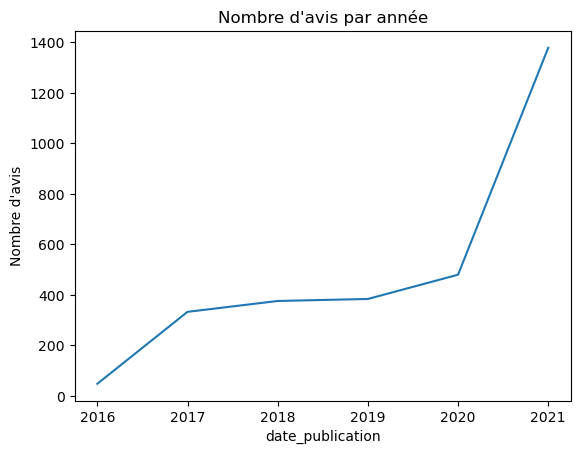

In [ ]:
df_final["date_publication"] = pd.to_datetime(df_final["date_publication"], dayfirst=True)

df_final.groupby(df_final["date_publication"].dt.year).size().plot()
plt.title("Numbers of reviews per year")
plt.ylabel("Number of reviews")
plt.show()


The number of reviews varies over time, showing that customer feedback is not uniformly distributed across years. This temporal variability may reflect growth in platform usage, changes in customer behavior, or external events affecting the insurance sector.

#### Length of comments

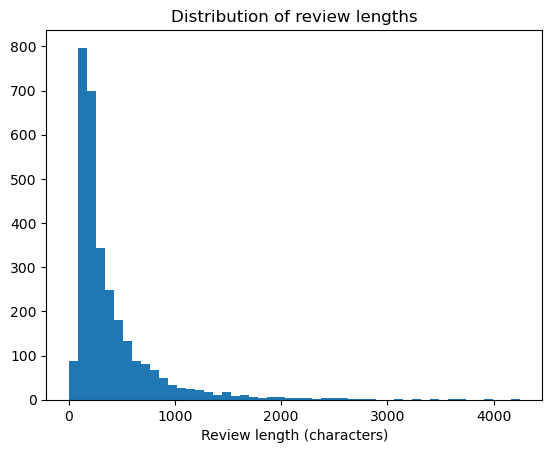

In [11]:
df_final["longueur_avis"] = df_final["avis"].str.len()

plt.hist(df_final["longueur_avis"], bins=50)
plt.title("Distribution of review lengths")
plt.xlabel("Review length (characters)")
plt.show()


The reviews are far from being short comments only. The average length is about 393 characters, while the median is 237 characters, which indicates that many users provide substantial textual information. At the same time, the very large gap between the median and the maximum value (4,245 characters) reveals a highly right-skewed distribution: most reviews are moderate in length, but a small number are extremely long.

This asymmetry is important in NLP. Longer reviews generally contain richer semantic information, more precise descriptions of customer experience, and more domain-specific vocabulary. They can therefore be useful for tasks such as topic modeling or sentiment classification. However, they may also introduce noise, repetitions, or multiple themes in a single review, which makes prediction harder.

The presence of only a few extremely short comments is also informative. Reviews with one or two words such as “Nul”, “Bof” or “à fuir” are rare, but they are challenging because they contain very little context. Their meaning is usually strongly emotional, yet they provide limited lexical diversity. This kind of edge case may reduce model robustness if not considered carefully.

#### Word cloud

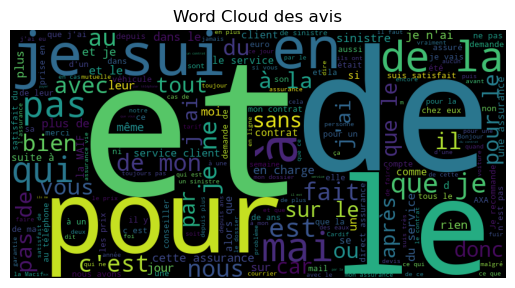

In [ ]:
text = " ".join(df_final["avis"].dropna())
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Reviews in french")
plt.show()


Most frequent words

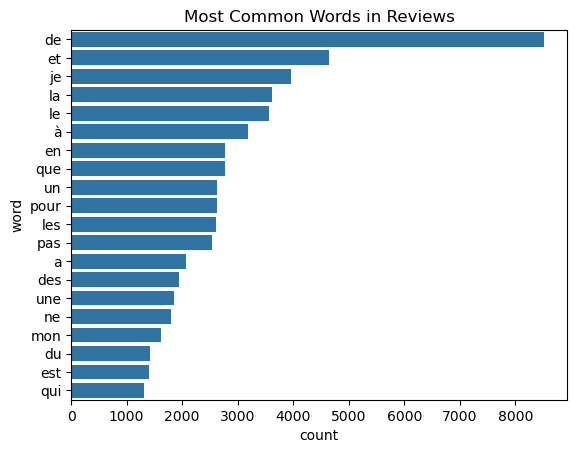

In [14]:
words = " ".join(df_final["avis"].dropna()).lower().split()

common_words = Counter(words).most_common(20)

words_df = pd.DataFrame(common_words, columns=["word", "count"])

sns.barplot(data=words_df, x="count", y="word")
plt.title("Most Common Words in Reviews")
plt.show()


The most frequent raw words provide a first overview of the lexical universe of the corpus, but they should not be overinterpreted at this stage. In raw text, highly frequent words often reflect the domain itself rather than the true semantic structure of customer feedback.

This is precisely why preprocessing is essential. Without cleaning, stopword removal, and domain-specific filtering, the most visible lexical patterns may simply correspond to background vocabulary. The goal of the next preprocessing steps is therefore not to remove information arbitrarily, but to reduce lexical dominance from generic terms and reveal more meaningful semantic contrasts.

#### Length of reviews according to their grade

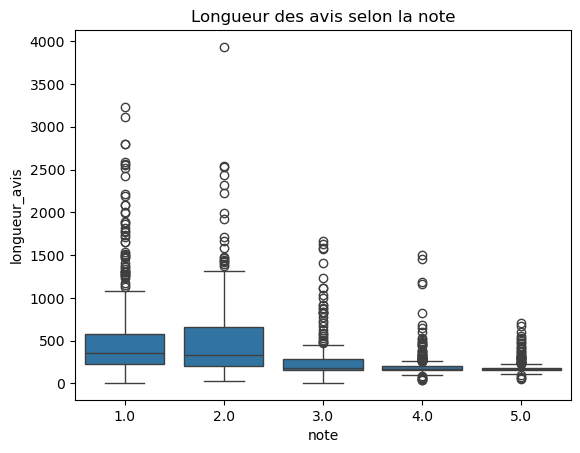

In [ ]:
sns.boxplot(data=df_final, x="note", y="longueur_avis")
plt.title("Review Length by Rating")
plt.show()

The boxplot shows that lower ratings (1 and 2) tend to have longer and more variable reviews, with many extreme values. This suggests that dissatisfied users are more likely to write detailed feedback.

In contrast, higher ratings (4 and 5) are associated with shorter and more consistent reviews, indicating that positive feedback is often more concise.

Overall, there is a clear relationship between rating and review length, with negative experiences generating more extensive comments.

#### Train/test distribution

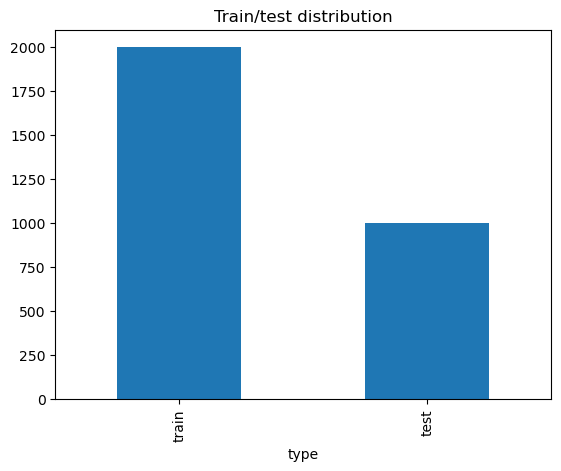

In [15]:
df_final["type"].value_counts().plot(kind="bar")
plt.title("Train/test distribution")
plt.show()

## Correction of the french text

### Validating the Text Cleaning Functions
Cleaning code can silently over-normalize the text, so we test it on a few hand-crafted examples before applying it at scale. The examples below include numbers, repeated spaces, and missing values because those are common failure modes in review corpora.


In [ ]:
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r"\d+", "", text) # Delete numbers
    text = re.sub(r"\s+", " ", text) # Delete extra spaces
    return text.strip()

df_final["avis_clean"] = df_final["avis"].apply(clean_text)


In [ ]:
# Validate the French cleaning helper on representative edge cases.
sample_cases = [
    'Service 123 très lent   mais efficace',
    '  ',
    None,
    'Remboursement en 2 jours, parfait !',
]

for raw_text in sample_cases:
    cleaned_text = clean_text(raw_text)
    print({'raw': raw_text, 'cleaned': cleaned_text})


Spelling correction was applied to the French reviews before translation. This order is coherent because translation systems generally perform better when the source text is more standardized. Correcting the French text first helps reduce noise caused by typographical errors, informal spelling, or inconsistent wording.

The subsequent translation into English serves a practical objective: it makes the corpus easier to process with a broader range of NLP tools and pretrained resources, especially for embeddings and transformer-based models that are often more mature in English.

In [ ]:
spell = SpellChecker(language='fr')

def build_protected_words(df):
    protected = set()
    
    for col in ["assureur", "produit"]:
        if col in df.columns:
            for val in df[col].dropna().astype(str).unique():
                val = val.replace("’", "'").lower()
                protected.add(val)
                for token in re.findall(r"[a-zàâäçéèêëîïôöùûüÿñæœ0-9']+", val):
                    protected.add(token)
    
    protected.update({
        'Direct Assurance', "L'olivier Assurance", 'Matmut',
       'Néoliane Santé', 'APRIL', 'SantéVet', 'Mercer', 'Generali',
       'Allianz', 'APRIL Moto', 'Cegema Assurances', 'LCL', 'Afer',
       'Pacifica', 'SwissLife', 'MAAF', 'Solly Azar', 'GMF', 'AMV',
       'CNP Assurances', 'MAIF', 'Sogecap', 'Harmonie Mutuelle',
       'Mutuelle des Motards', 'MACIF', 'Eurofil', 'Active Assurances',
       'AXA', 'Sogessur', 'Ag2r La Mondiale', 'Mgen', "Zen'Up", 'MGP',
       'Intériale', 'Génération', 'Cardif', 'Santiane', 'Eca Assurances',
       'Groupama', "Assur O'Poil", 'MMA', 'MetLife', 'Crédit Mutuel',
       'Afi Esca', 'Gan', 'Magnolia', 'Suravenir', 'Assur Bon Plan',
       'AssurOnline', 'Carac', 'Mapa', 'Malakoff Humanis'
    })
    
    return protected


def smart_correct_text(text, protected_words):
    if pd.isna(text):
        return text
    
    tokens = text.split()
    corrected = []
    
    for token in tokens:
        tok = token.lower()
        
        if tok in protected_words:
            corrected.append(token)
            continue
        
        if "'" in tok:
            corrected.append(token)
            continue
        
        if tok.isdigit() or len(tok) <= 2:
            corrected.append(token)
            continue
        
        suggestion = spell.correction(tok)
        
        if suggestion is None:
            corrected.append(token)
        else:
            corrected.append(suggestion)
    
    return " ".join(corrected)

protected_words = build_protected_words(df_final)

df_final["avis_corrected"] = df_final["avis_clean"].progress_apply(
    lambda x: smart_correct_text(x, protected_words)
)


100%|██████████| 3000/3000 [41:06<00:00,  1.22it/s]  


## Translation of the french text

We then translated the reviews in english using deep_translator.

In [ ]:
from deep_translator import GoogleTranslator

df_final["avis_translate"] = df_final["avis_corrected"].progress_apply(
    lambda x: GoogleTranslator(source="fr", target="en").translate(x)
)


100%|██████████| 3000/3000 [32:10<00:00,  1.55it/s]


#### Different cleaning for TF-IDF or embeddings

We first translate all reviews from French to English to ensure consistency across the dataset and compatibility with downstream NLP models.

Here, we apply different text cleaning strategies depending on the intended use of the data.

For TF-IDF and LDA, we perform a strong cleaning by removing stopwords (including domain-specific terms), punctuation, and short tokens. This produces a normalized and compact representation suitable for frequency-based methods.

For embeddings and transformer-based models, we apply a lighter cleaning. The text is preserved as much as possible, with only minimal normalization, in order to retain semantic richness and contextual information.

This distinction allows us to adapt preprocessing to the requirements of each modelling approach.

In [ ]:
DOMAIN_STOPWORDS_EN = {
    "insurance", "insurer", "insurers", "contract", "service", "services", "customer", "customers",
    "company", "companies", "claim", "claims", "case", "file", "website", "phone", "advisor", "advisors"
}

def clean_english_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace("’", "'")
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def prepare_english_for_tfidf_or_lda(text: str) -> str:
    cleaned = clean_english_text(text)
    tokens = [
        token for token in cleaned.split()
        if token not in ENGLISH_STOP_WORDS and token not in DOMAIN_STOPWORDS_EN and len(token) > 2
    ]
    return " ".join(tokens)

def normalize_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def prepare_english_for_embeddings_or_bert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("’", "'")
    text = re.sub(r"\n+", " ", text)
    text = normalize_spaces(text)
    return text.strip()

df_final["avis_en_clean"] = df_final["avis_translate"].apply(clean_english_text)
df_final["avis_en_tfidf_lda"] = df_final["avis_translate"].apply(prepare_english_for_tfidf_or_lda)
df_final["avis_en_embeddings"] = df_final["avis_translate"].apply(prepare_english_for_embeddings_or_bert)

df_final[["avis_translate", "avis_en_tfidf_lda", "avis_en_embeddings"]].head(10)


,avis_translate,avis_en_tfidf_lda,avis_en_embeddings
0,best insurance prices solutions listening speed and I recommend this company for you attractive prices and quality and speed services,best prices solutions listening speed recommend attractive prices quality speed,best insurance prices solutions listening speed and I recommend this company for you attractive prices and quality and speed services
1,"I am generally satisfied, except that you have a problem with your internal site, it is impossible to declare a claim online after several attempts, declaration made by telephone or everything went very well, competent and very pleasant interlocutor",generally satisfied problem internal site impossible declare online attempts declaration telephone went competent pleasant interlocutor,"I am generally satisfied, except that you have a problem with your internal site, it is impossible to declare a claim online after several attempts, declaration made by telephone or everything went very well, competent and very pleasant interlocutor"
2,very affordable price several options are available to us such as the box connected to the car the reassurance option and zero franchise which is quite pleasant,affordable price options available box connected car reassurance option zero franchise quite pleasant,very affordable price several options are available to us such as the box connected to the car the reassurance option and zero franchise which is quite pleasant
3,"I am satisfied with the service, a very quick response from your service, I thank you for it, you are the cheapest insurance on the market, best regards",satisfied quick response thank cheapest market best regards,"I am satisfied with the service, a very quick response from your service, I thank you for it, you are the cheapest insurance on the market, best regards"
4,customer for more than years very disappointed with this mutual which no longer has anything of a mutual the search for immediate profit has become their priority at the agency we only know to try to cheat you out of useless contracts we make you pay for legal protection on each contract but you will only be defended once as soon as there is the slightest disaster they are not there to defend you but on the contrary to automatically put all the wrongs on you to lower your bonus which is too high! in short they only have one goal to make you pay as much as possible unfortunately this is now the lot of all insurers so try to pay as little as possible and above all not to need them!!!,years disappointed mutual longer mutual search immediate profit priority agency know try cheat useless contracts make pay legal protection defended soon slightest disaster defend contrary automatically wrongs lower bonus high short goal make pay possible unfortunately lot try pay little possible need,customer for more than years very disappointed with this mutual which no longer has anything of a mutual the search for immediate profit has become their priority at the agency we only know to try to cheat you out of useless contracts we make you pay for legal protection on each contract but you will only be defended once as soon as there is the slightest disaster they are not there to defend you but on the contrary to automatically put all the wrongs on you to lower your bonus which is too high! in short they only have one goal to make you pay as much as possible unfortunately this is now the lot of all insurers so try to pay as little as possible and above all not to need them!!!
5,"forced sale by telephone claiming serious events for my loved ones but without even knowing my date of birth! Néoliane will say that it is the fault of the telephone platform in Magreb, but this canvassing is abusive and distressing, moreover I am registered on bloctel to flee and report to the fraud repression services",forced sale telephone claiming events loved ones knowing date birth oliane say fault telephone platform magreb canvassing abusive distressing reg

#### Sanity Check for the Two English Text Variants

In [ ]:
# Compare the two English cleaning strategies on a small sample.
comparison_columns = ['avis_translate', 'avis_en_tfidf_lda', 'avis_en_embeddings']
print(df_final[comparison_columns].head(5))
print('Missing values in cleaned English columns:')
print(df_final[['avis_en_tfidf_lda', 'avis_en_embeddings']].isna().sum())


We perform a quick sanity check to compare the different English text versions generated during preprocessing. By displaying a few examples, we visually verify that the cleaning strategies produce distinct outputs.

We also check for missing values in the cleaned columns to ensure that no data was lost during the transformation process.

## Clean text analysis

#### Frequent words

In [ ]:
words = " ".join(df_final["avis_en_tfidf_lda"].fillna("").astype(str)).split()
freq = Counter(words).most_common(20)
print(freq)


[('years', 668), ('satisfied', 572), ('good', 452), ('price', 439), ('time', 418), ('months', 382), ('pay', 347), ("it's", 340), ('prices', 337), ('following', 335), ('year', 321), ('recommend', 317), ('telephone', 317), ('contact', 315), ('does', 313), ('insured', 308), ('car', 300), ('expert', 295), ('problem', 273), ('euros', 267)]


<Axes: xlabel='count', ylabel='word'>

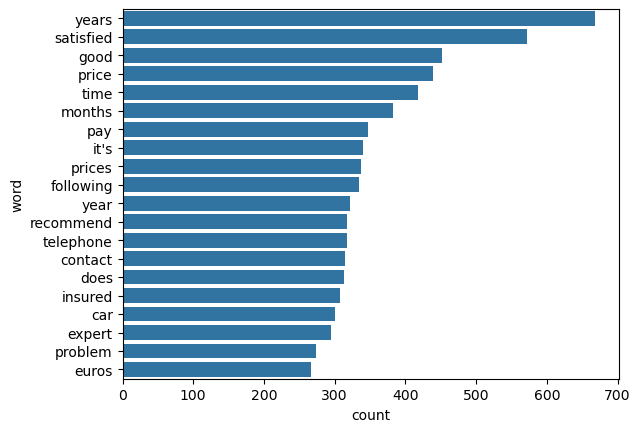

In [ ]:
freq_df = pd.DataFrame(freq, columns=["word","count"])

sns.barplot(data=freq_df, x="count", y="word")

After cleaning, the most frequent words are no longer dominated by purely generic vocabulary. Instead, the corpus highlights terms such as `satisfied`, `price`, `time`, `months`, `pay`, `recommend`, `telephone`, `contact`, `problem`, and `euros`.

This shift is important because it suggests that preprocessing successfully removed part of the domain background noise and brought forward more experience-centered vocabulary. The resulting lexical field seems to revolve around a few major dimensions of customer experience: cost, service interaction, duration or delays, and evaluative judgment.

#### n-grams

In [ ]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english")

X = vectorizer.fit_transform(df_final["avis_en_tfidf_lda"])

ngrams = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0])

ngrams_df = pd.DataFrame(ngrams, columns=["bigram","count"])
ngrams_df = ngrams_df.sort_values("count", ascending=False).head(20)


<Axes: xlabel='count', ylabel='bigram'>

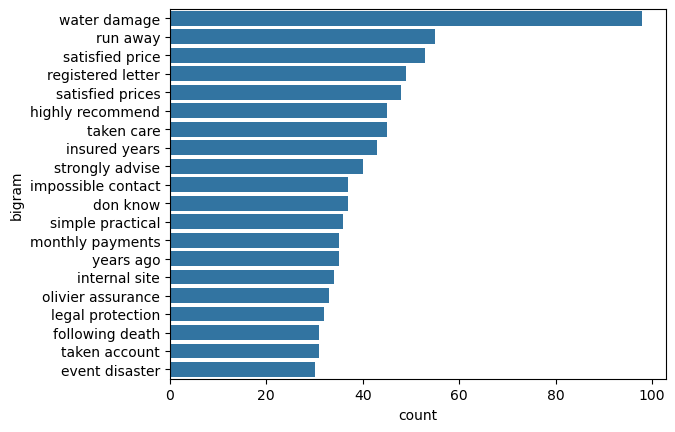

In [ ]:
sns.barplot(data=ngrams_df, x="count", y="bigram")

Bigram analysis is especially useful because isolated words often remain ambiguous, whereas short word combinations reveal more meaningful patterns. In review corpora, n-grams can capture recurring expressions linked to claims management, delays, reimbursement, pricing, or customer support.

Compared with single word frequency analysis, bigrams provide a more operational view of the corpus. They help identify repeated situations, which is particularly valuable for topic modeling.

## Final Validation Before Export
The last check confirms that the cleaned file contains the columns expected by the downstream notebooks. This validation is important for a final submission because it demonstrates reproducibility across notebooks.


In [ ]:
# Confirm that the exported dataset contains the columns required later.
required_columns = [
    'avis', 'note', 'type', 'avis_corrected', 'avis_translate',
    'avis_en_tfidf_lda', 'avis_en_embeddings'
]
missing_required_columns = [col for col in required_columns if col not in df_final.columns]
print('Missing required columns:', missing_required_columns)
assert not missing_required_columns, 'The cleaned dataset is missing columns required by later notebooks.'


In [ ]:
df_final.to_csv("dataset_cleaned.csv", index=False)